In [20]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
# descarga de datos
df_nvidia = yf.download('NVDA', period='5y', interval='1d')

# limpieza
df_nvidia.columns = df_nvidia.columns.get_level_values(0)
df_nvidia.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [22]:
# creamos columna de retorno
df_nvidia['Retorno'] = df_nvidia['Close'].pct_change() * 100
df_nvidia.dropna(inplace=True)

# calculamos desviacion estandar con .std
desviacion_estandar = df_nvidia['Retorno'].std() # .std() genera desviacion estandar

# calculamos el sesgo con .skew()
sesgo = df_nvidia['Retorno'].skew()

# calculamos la curtosis con .kurt()
curtosis = df_nvidia['Retorno'].kurt()

print(f'La desviacion estandar de los ultimos 6 meses de NVIDIA es: {desviacion_estandar}')
print(f'El sesgo de los ultimos 6 meses de NVIDIA es: {sesgo}')
print(f'La curtosis de los ultimos 6 meses de NVIDIA es: {curtosis}')


La desviacion estandar de los ultimos 6 meses de NVIDIA es: 3.253259557829283
El sesgo de los ultimos 6 meses de NVIDIA es: 0.5453534801569216
La curtosis de los ultimos 6 meses de NVIDIA es: 4.737462724239867


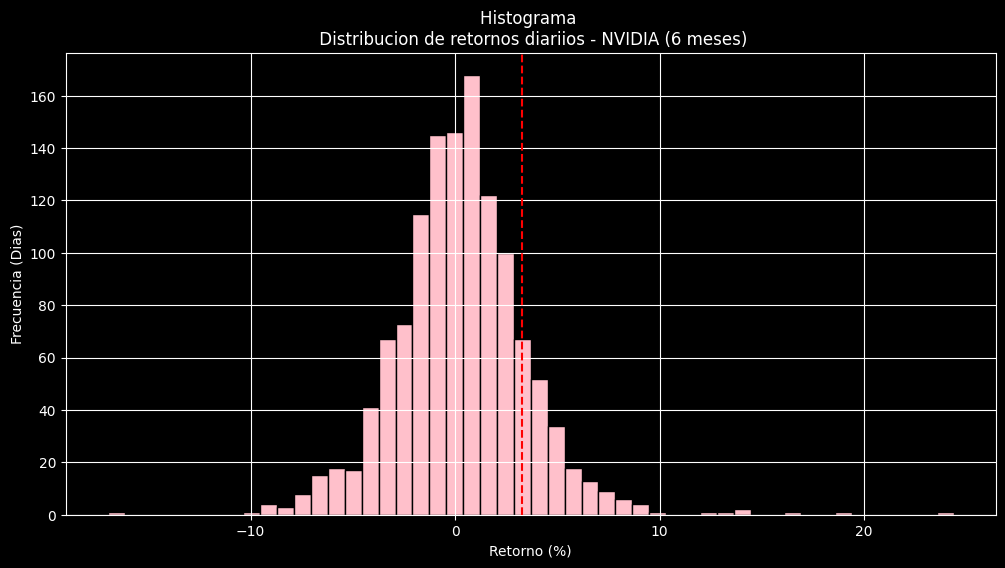

In [23]:
# histograma
plt.figure(figsize=(12, 6))
plt.hist(df_nvidia['Retorno'], bins=50, color='pink', edgecolor='black')
plt.axvline(desviacion_estandar, color='red', linestyle='dashed', label='STD Dev')

# etiquetas
plt.title('Histograma \n Distribucion de retornos diariios - NVIDIA (6 meses)')
plt.xlabel('Retorno (%)')
plt.ylabel('Frecuencia (Dias)')

plt.grid(True)
plt.show()

In [24]:
# creamos un estrategia basica
# si el retorno es mayor a la std es una signal
# creamos la columna
df_nvidia['Signal'] = df_nvidia['Retorno'] <- desviacion_estandar

# hacemos el conteo de veces que ocurrio la signal en los 6 meses descargados
signal_count = df_nvidia['Signal'].sum()
print(f'The signal got active {signal_count} times in 6 months')

# calculo de probabilidad de que ocurra
signal_probability = (signal_count / len(df_nvidia) * 100)
print(f'La probabilidad de que ocurra es de: {signal_probability}')

# movemos los datos un lugar hacia atras (para comparar hoy con manana) usamos .shift(-1)
df_nvidia['Tomorrow_return'] = df_nvidia['Retorno'].shift(-1)

# variable que sirve para ver solo los dias donde hay signal
just_signals = df_nvidia[df_nvidia['Signal'] == True]

# promedio del dia despues de la signal
post_signal_mean = just_signals['Tomorrow_return'].dropna().mean()
print(f'El retorno promedio del dia despues de la signal es de: {post_signal_mean}')

# promedio normal de todos los dias
normal_mean = df_nvidia['Retorno'].mean()
print(f'El retorno promedio normal de NVIDIA es: {normal_mean}')

# retorno minimo y maximo
max = df_nvidia['Tomorrow_return'].max()
min = df_nvidia['Tomorrow_return'].min()
print(f'El retorno maximo fue: {max}')
print(f'El retorno minimo fue: {min}')

# cuantas de las 14 veces de la signal fueron ganadoras
winners = (just_signals['Tomorrow_return'] > 0).sum()

# win rate
win_rate = (winners / len(just_signals)) * 100
print(f'Win rate: {win_rate}%')

# promedio de ganancias
avg_earnings = just_signals[just_signals['Tomorrow_return'] > 0]['Tomorrow_return'].mean()

# promedio de perdidas
avg_loss = just_signals[just_signals['Tomorrow_return'] < 0]['Tomorrow_return'].abs().mean()

# calculo de expentancy
expentancy = (0.5 * avg_earnings) - (0.5 * avg_loss)
print(f'Expentancy: {expentancy}')

The signal got active 150 times in 6 months
La probabilidad de que ocurra es de: 11.952191235059761
El retorno promedio del dia despues de la signal es de: 0.6835360983058831
El retorno promedio normal de NVIDIA es: 0.25491068845091414
El retorno maximo fue: 24.369643569908384
El retorno minimo fue: -16.968169831960267
Win rate: 56.00000000000001%
Expentancy: 0.35590344811977603
